# Company U Library Genre Analysis & Visualization

Comprehensive analysis and visualization of the Company U library collection, including genre distribution, language breakdown, and checkout patterns.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported")

✅ All libraries imported


## Load Data

In [2]:
# Load the Company U genre classification output
df = pd.read_csv('company_u_genres_output.csv', encoding='utf-8')

# Remove summary rows
df = df[df['Title'] != 'SUMMARY'].copy()
df = df[df['Title'] != ''].copy()

print(f"Loaded {len(df)} books from Company U collection")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Loaded 667 books from Company U collection

DataFrame shape: (667, 4)

First few rows:
                                               Title  Number  \
0                            the bastard of istanbul     3.0   
1  business model generation a handbook for visio...     3.0   
2                                    college algebra     3.0   
3                                 kafka on the shore     3.0   
4        the norton anthology of american literature     3.0   

                   language                         Genres  
0                   English      Horror, Fantasy, Thriller  
1                   English   Nonfiction, Fantasy, Mystery  
2  Latin (Unknown language)  Nonfiction, Thriller, Mystery  
3                   English  Nonfiction, Fantasy, Thriller  
4                   English     Thriller, Fantasy, Mystery  


## Genre Analysis

In [3]:
# Parse genres (comma-separated strings)
all_genres = []
genre_counts = Counter()
genre_checkouts = Counter()

for idx, row in df.iterrows():
    genres_str = str(row['Genres']).strip()
    if genres_str and genres_str != 'nan':
        genres = [g.strip() for g in genres_str.split(',')]
        for genre in genres:
            genre_counts[genre] += 1
            genre_checkouts[genre] += row['Number']
        all_genres.extend(genres)

print(f"Total books with genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"\nGenre Distribution (by title count):")
for genre, count in genre_counts.most_common():
    print(f"  {genre}: {count} books")

Total books with genres: 666

Genre Distribution (by title count):
  Nonfiction: 616 books
  Mystery: 400 books
  Fantasy: 218 books
  Thriller: 213 books
  Young Adult: 180 books
  Horror: 48 books
  Science Fiction: 41 books
  Romance: 38 books
  Biography: 28 books
  Historical Fiction: 25 books


## Genre Distribution Chart

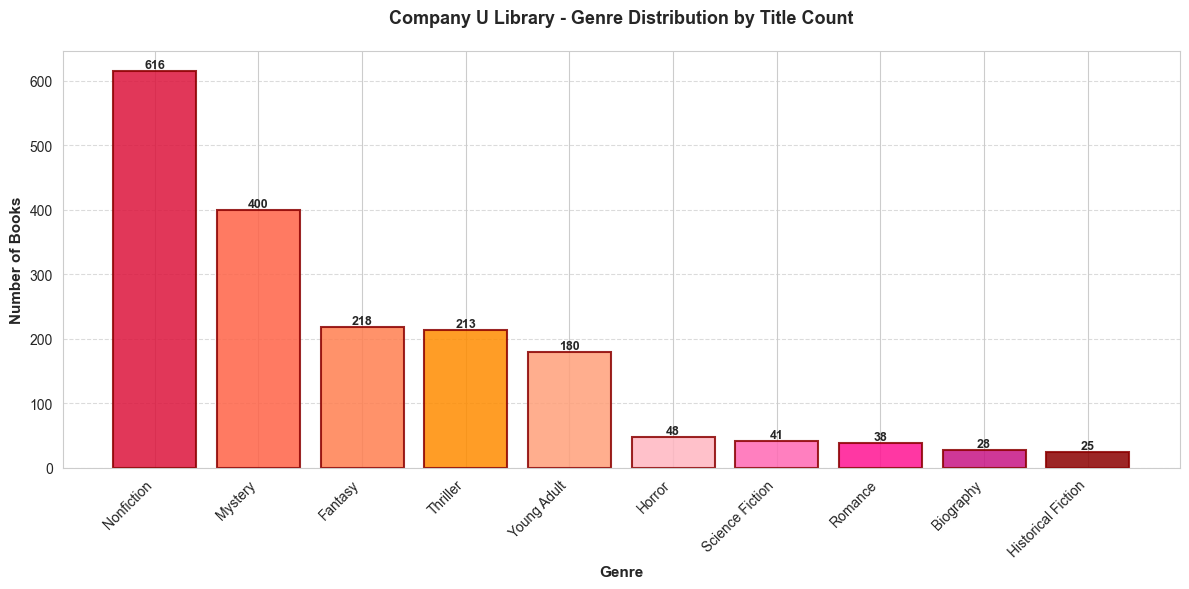

✅ Saved graphs/company_u_genre_distribution.png


In [4]:
# Create genre distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_counts.most_common()).keys())
counts = [genre_counts[g] for g in genres]

# Use red/coral color palette
colors = ['#DC143C', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors = colors[:len(genres)]

bars = ax.bar(genres, counts, color=colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_title('Company U Library - Genre Distribution by Title Count', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_u_genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_genre_distribution.png")

## Language Distribution Chart

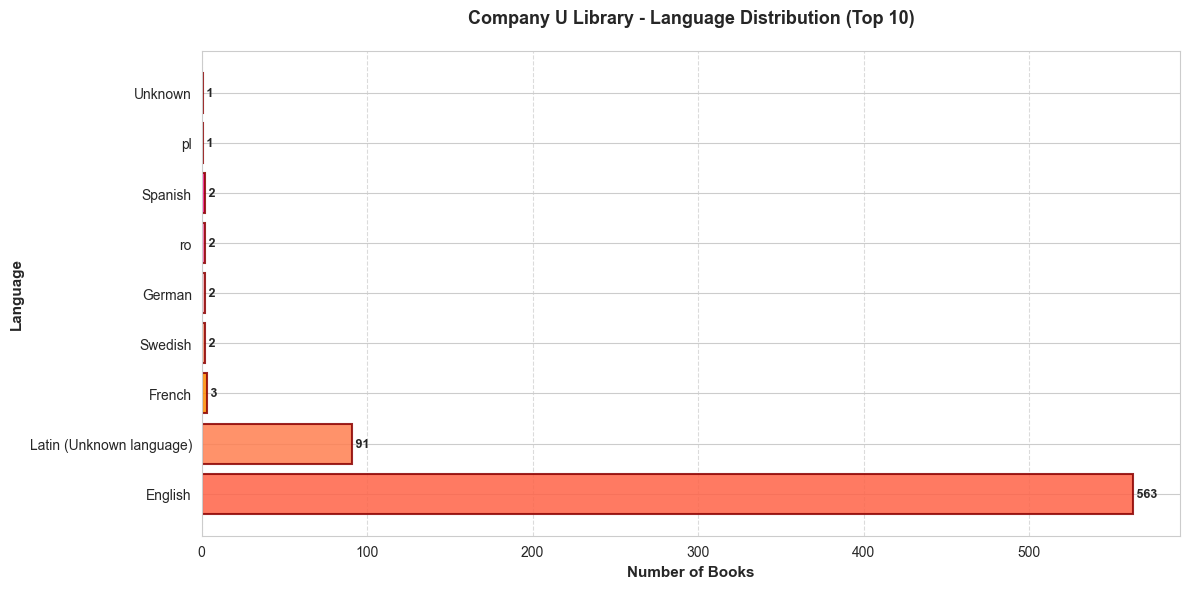

✅ Saved graphs/company_u_language_distribution.png


In [5]:
# Analyze language distribution
language_counts = Counter(df['language'].fillna('Unknown'))

# Language code to full name mapping
LANGUAGE_NAMES = {
    "en": "English",
    "sv": "Swedish",
    "ru": "Russian",
    "hy": "Armenian",
    "tr": "Turkish",
    "fr": "French",
    "es": "Spanish",
    "de": "German",
    "ar": "Arabic",
    "ja": "Japanese",
    "ko": "Korean",
    "zh": "Chinese",
    "pt": "Portuguese",
    "it": "Italian",
    "el": "Greek",
    "he": "Hebrew",
    "cyr": "Cyrillic",
    "cjk": "CJK",
    "latin": "Latin",
    "Unknown": "Unknown"
}

fig, ax = plt.subplots(figsize=(12, 6))

langs_codes = list(dict(language_counts.most_common(10)).keys())
langs_names = [LANGUAGE_NAMES.get(code, code) for code in langs_codes]
lang_counts = [language_counts[l] for l in langs_codes]

# Use coral/darkred palette
lang_colors = ['#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000', '#696969']
lang_colors = lang_colors[:len(langs_names)]

bars = ax.barh(langs_names, lang_counts, color=lang_colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, lang_counts)):
    ax.text(count, bar.get_y() + bar.get_height()/2.,
            f' {int(count)}',
            ha='left', va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_ylabel('Language', fontsize=11, fontweight='bold')
ax.set_title('Company U Library - Language Distribution (Top 10)', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graphs/company_u_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_language_distribution.png")

## Genre Volume Distribution (Total Checkouts)

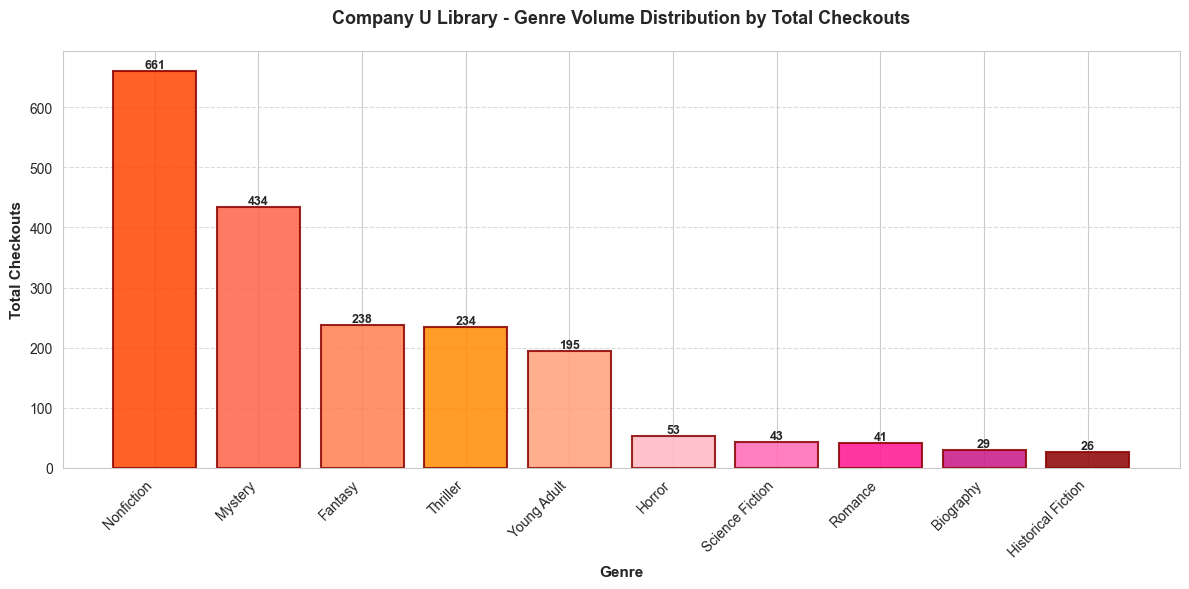

✅ Saved graphs/company_u_genre_volume.png


In [6]:
# Create volume distribution chart (total checkouts by genre)
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_checkouts.most_common()).keys())
volumes = [genre_checkouts[g] for g in genres]

# Use red/darkred gradient
colors_vol = ['#FF4500', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors_vol = colors_vol[:len(genres)]

bars = ax.bar(genres, volumes, color=colors_vol, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Checkouts', fontsize=11, fontweight='bold')
ax.set_title('Company U Library - Genre Volume Distribution by Total Checkouts', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_u_genre_volume.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_genre_volume.png")

## Summary Statistics

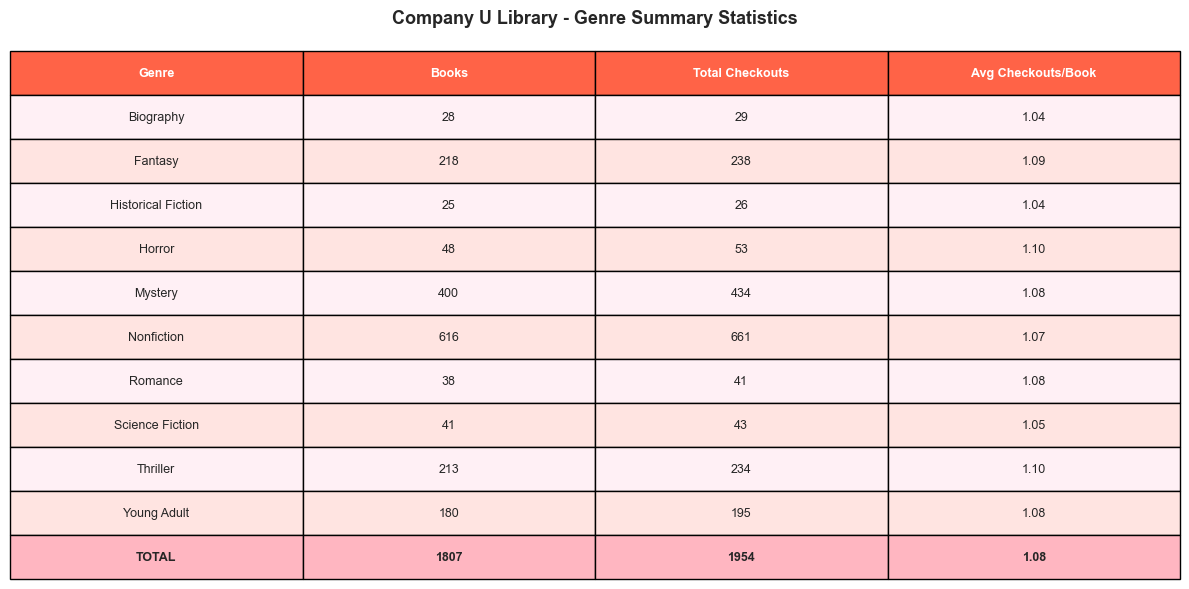

✅ Saved graphs/company_u_summary_statistics.png


In [8]:
# Create comprehensive summary statistics table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Prepare summary data
summary_stats = []
for genre in sorted(genre_counts.keys()):
    title_count = genre_counts[genre]
    total_checkouts = genre_checkouts[genre]
    avg_checkouts = total_checkouts / title_count if title_count > 0 else 0
    summary_stats.append([
        genre,
        f"{title_count}",
        f"{int(total_checkouts)}",
        f"{avg_checkouts:.2f}"
    ])

# Add totals row
total_books = sum(genre_counts.values())
total_checkouts_all = sum(genre_checkouts.values())
summary_stats.append([
    "TOTAL",
    f"{total_books}",
    f"{int(total_checkouts_all)}",
    f"{total_checkouts_all/total_books:.2f}"
])

# Create table
columns = ['Genre', 'Books', 'Total Checkouts', 'Avg Checkouts/Book']
table = ax.table(cellText=summary_stats, colLabels=columns, cellLoc='center',
                  loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#FF6347')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style total row
for i in range(len(columns)):
    table[(len(summary_stats), i)].set_facecolor('#FFB6C1')
    table[(len(summary_stats), i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, len(summary_stats)):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#FFE4E1')
        else:
            table[(i, j)].set_facecolor('#FFF0F5')

plt.title('Company U Library - Genre Summary Statistics', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graphs/company_u_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_u_summary_statistics.png")

## Final Summary Report

In [9]:
print("\n" + "="*70)
print("COMPANY U LIBRARY COLLECTION - FINAL ANALYSIS REPORT")
print("="*70)

# Language code to full name mapping
LANGUAGE_NAMES = {
    "en": "English",
    "sv": "Swedish",
    "ru": "Russian",
    "hy": "Armenian",
    "tr": "Turkish",
    "fr": "French",
    "es": "Spanish",
    "de": "German",
    "ar": "Arabic",
    "ja": "Japanese",
    "ko": "Korean",
    "zh": "Chinese",
    "pt": "Portuguese",
    "it": "Italian",
    "el": "Greek",
    "he": "Hebrew",
    "cyr": "Cyrillic",
    "cjk": "CJK",
    "latin": "Latin",
    "Unknown": "Unknown"
}

print(f"\n📚 COLLECTION OVERVIEW:")
print(f"  Total Books: {len(df)}")
print(f"  Books with Genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"  Total Checkouts: {int(df['Number'].sum())}")
print(f"  Unique Languages: {df['language'].nunique()}")

print(f"\n🎭 TOP GENRES:")
total_books = sum(genre_counts.values())
total_checkouts_all = sum(genre_checkouts.values())
for genre, count in genre_counts.most_common(5):
    checkouts = genre_checkouts[genre]
    pct = (count / total_books * 100)
    print(f"  {genre:20s}: {count:3d} books ({pct:5.1f}%) | {int(checkouts):3d} checkouts")

print(f"\n🌍 TOP LANGUAGES:")
for lang_code, count in language_counts.most_common(5):
    lang_name = LANGUAGE_NAMES.get(lang_code, lang_code)
    pct = (count / len(df) * 100)
    print(f"  {lang_name:20s}: {count:3d} books ({pct:5.1f}%)")

print(f"\n📊 CHECKOUT STATISTICS:")
print(f"  Average Checkouts per Book: {df['Number'].mean():.2f}")
print(f"  Median Checkouts per Book: {df['Number'].median():.0f}")
print(f"  Max Checkouts for Single Book: {df['Number'].max():.0f}")
print(f"  Min Checkouts for Single Book: {df['Number'].min():.0f}")

print(f"\n✅ Visualizations generated:")
print(f"  - company_u_genre_distribution.png")
print(f"  - company_u_language_distribution.png")
print(f"  - company_u_genre_volume.png")
print(f"  - company_u_genre_composition.png")
print(f"  - company_u_summary_statistics.png")
print("\n" + "="*70)


COMPANY U LIBRARY COLLECTION - FINAL ANALYSIS REPORT

📚 COLLECTION OVERVIEW:
  Total Books: 667
  Books with Genres: 666
  Total Checkouts: 718
  Unique Languages: 8

🎭 TOP GENRES:
  Nonfiction          : 616 books ( 34.1%) | 661 checkouts
  Mystery             : 400 books ( 22.1%) | 434 checkouts
  Fantasy             : 218 books ( 12.1%) | 238 checkouts
  Thriller            : 213 books ( 11.8%) | 234 checkouts
  Young Adult         : 180 books ( 10.0%) | 195 checkouts

🌍 TOP LANGUAGES:
  English             : 563 books ( 84.4%)
  Latin (Unknown language):  91 books ( 13.6%)
  French              :   3 books (  0.4%)
  Swedish             :   2 books (  0.3%)
  German              :   2 books (  0.3%)

📊 CHECKOUT STATISTICS:
  Average Checkouts per Book: 1.08
  Median Checkouts per Book: 1
  Max Checkouts for Single Book: 3
  Min Checkouts for Single Book: 1

✅ Visualizations generated:
  - company_u_genre_distribution.png
  - company_u_language_distribution.png
  - company_u_genre_